In [1]:
import matplotlib.pyplot as plt
import numpy as np
import os
from analysis_by_plot import draw_floorplan
from utils import spl

In [2]:
record_dir = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/yihe/records/'
experiment_id = 'test-4models' # 'test' #'moving-obstacle'#  #'test'     # 'steer_bias' #     
trial_id = 'sim_20240804_095014_random'    # 'sim_20240815_165142_random'# 

data_dir = os.path.join(record_dir, experiment_id, trial_id)

model_names = 'MB4ONdiagonal', 'MB4ONaxial', 'MB2ONbilateral', 'MB2ONopponent'
ls_color = 'tab:red', 'tab:blue', 'tab:orange', 'tab:green'

In [3]:
n_trial = 50
ls_var = 'x', 'y', 'f'

In [4]:
alldata = {}
for model_name in model_names:
    alldata[model_name] = {'steer': []}
    for var in ls_var:
        alldata[model_name][var] = []
        
    for trial in range(n_trial):
        data_name = 'Freight_{}_trial_{}_record.npz'.format(model_name, trial)
        data = np.load(os.path.join(data_dir, data_name), allow_pickle=True)
        alldata[model_name]['steer'].append(data['extra'][()]['steer_mode'])
        for var in ls_var:
            alldata[model_name][var].append(data[var])
            
scene_name = data['scene_name']
pos_start_goal = np.transpose([data['pos_start'][:2], data['pos_goal'][:2]])

In [5]:
print(pos_start_goal.T)

[[-0.69 -3.45]
 [-8.34  4.68]]


In [6]:
shortest_path, shortest_dist = np.array([[-0.69, -3.45],
       [-0.89, -3.25],
       [-1.09, -3.05],
       [-1.29, -2.85],
       [-1.49, -2.65],
       [-1.69, -2.45],
       [-1.89, -2.44],
       [-2.09, -2.37],
       [-2.29, -2.32],
       [-2.49, -2.15],
       [-2.69, -1.95],
       [-2.89, -1.89],
       [-3.09, -1.89],
       [-3.29, -1.89],
       [-3.41, -1.73],
       [-3.41, -1.53],
       [-3.41, -1.33],
       [-3.41, -1.13],
       [-3.51, -0.93],
       [-3.68, -0.73],
       [-3.68, -0.53],
       [-3.68, -0.33],
       [-3.69, -0.13],
       [-3.69,  0.07],
       [-3.69,  0.27],
       [-3.69,  0.47],
       [-3.69,  0.67],
       [-3.69,  0.87],
       [-3.69,  1.07],
       [-3.69,  1.27],
       [-3.79,  1.47],
       [-3.99,  1.67],
       [-4.19,  1.87],
       [-4.39,  2.07],
       [-4.59,  2.27],
       [-4.79,  2.47],
       [-4.99,  2.67],
       [-5.19,  2.87],
       [-5.39,  3.07],
       [-5.59,  3.27],
       [-5.79,  3.47],
       [-5.99,  3.61],
       [-6.19,  3.7 ],
       [-6.39,  3.79],
       [-6.59,  3.81],
       [-6.79,  3.81],
       [-6.99,  3.81],
       [-7.19,  3.81],
       [-7.39,  3.81],
       [-7.59,  3.81],
       [-7.79,  3.94],
       [-7.99,  4.08],
       [-8.15,  4.27],
       [-8.24,  4.47],
       [-8.34,  4.67]]), 12.868641404994282



Text(0.5, 1.0, 'Beechwood_0_int')

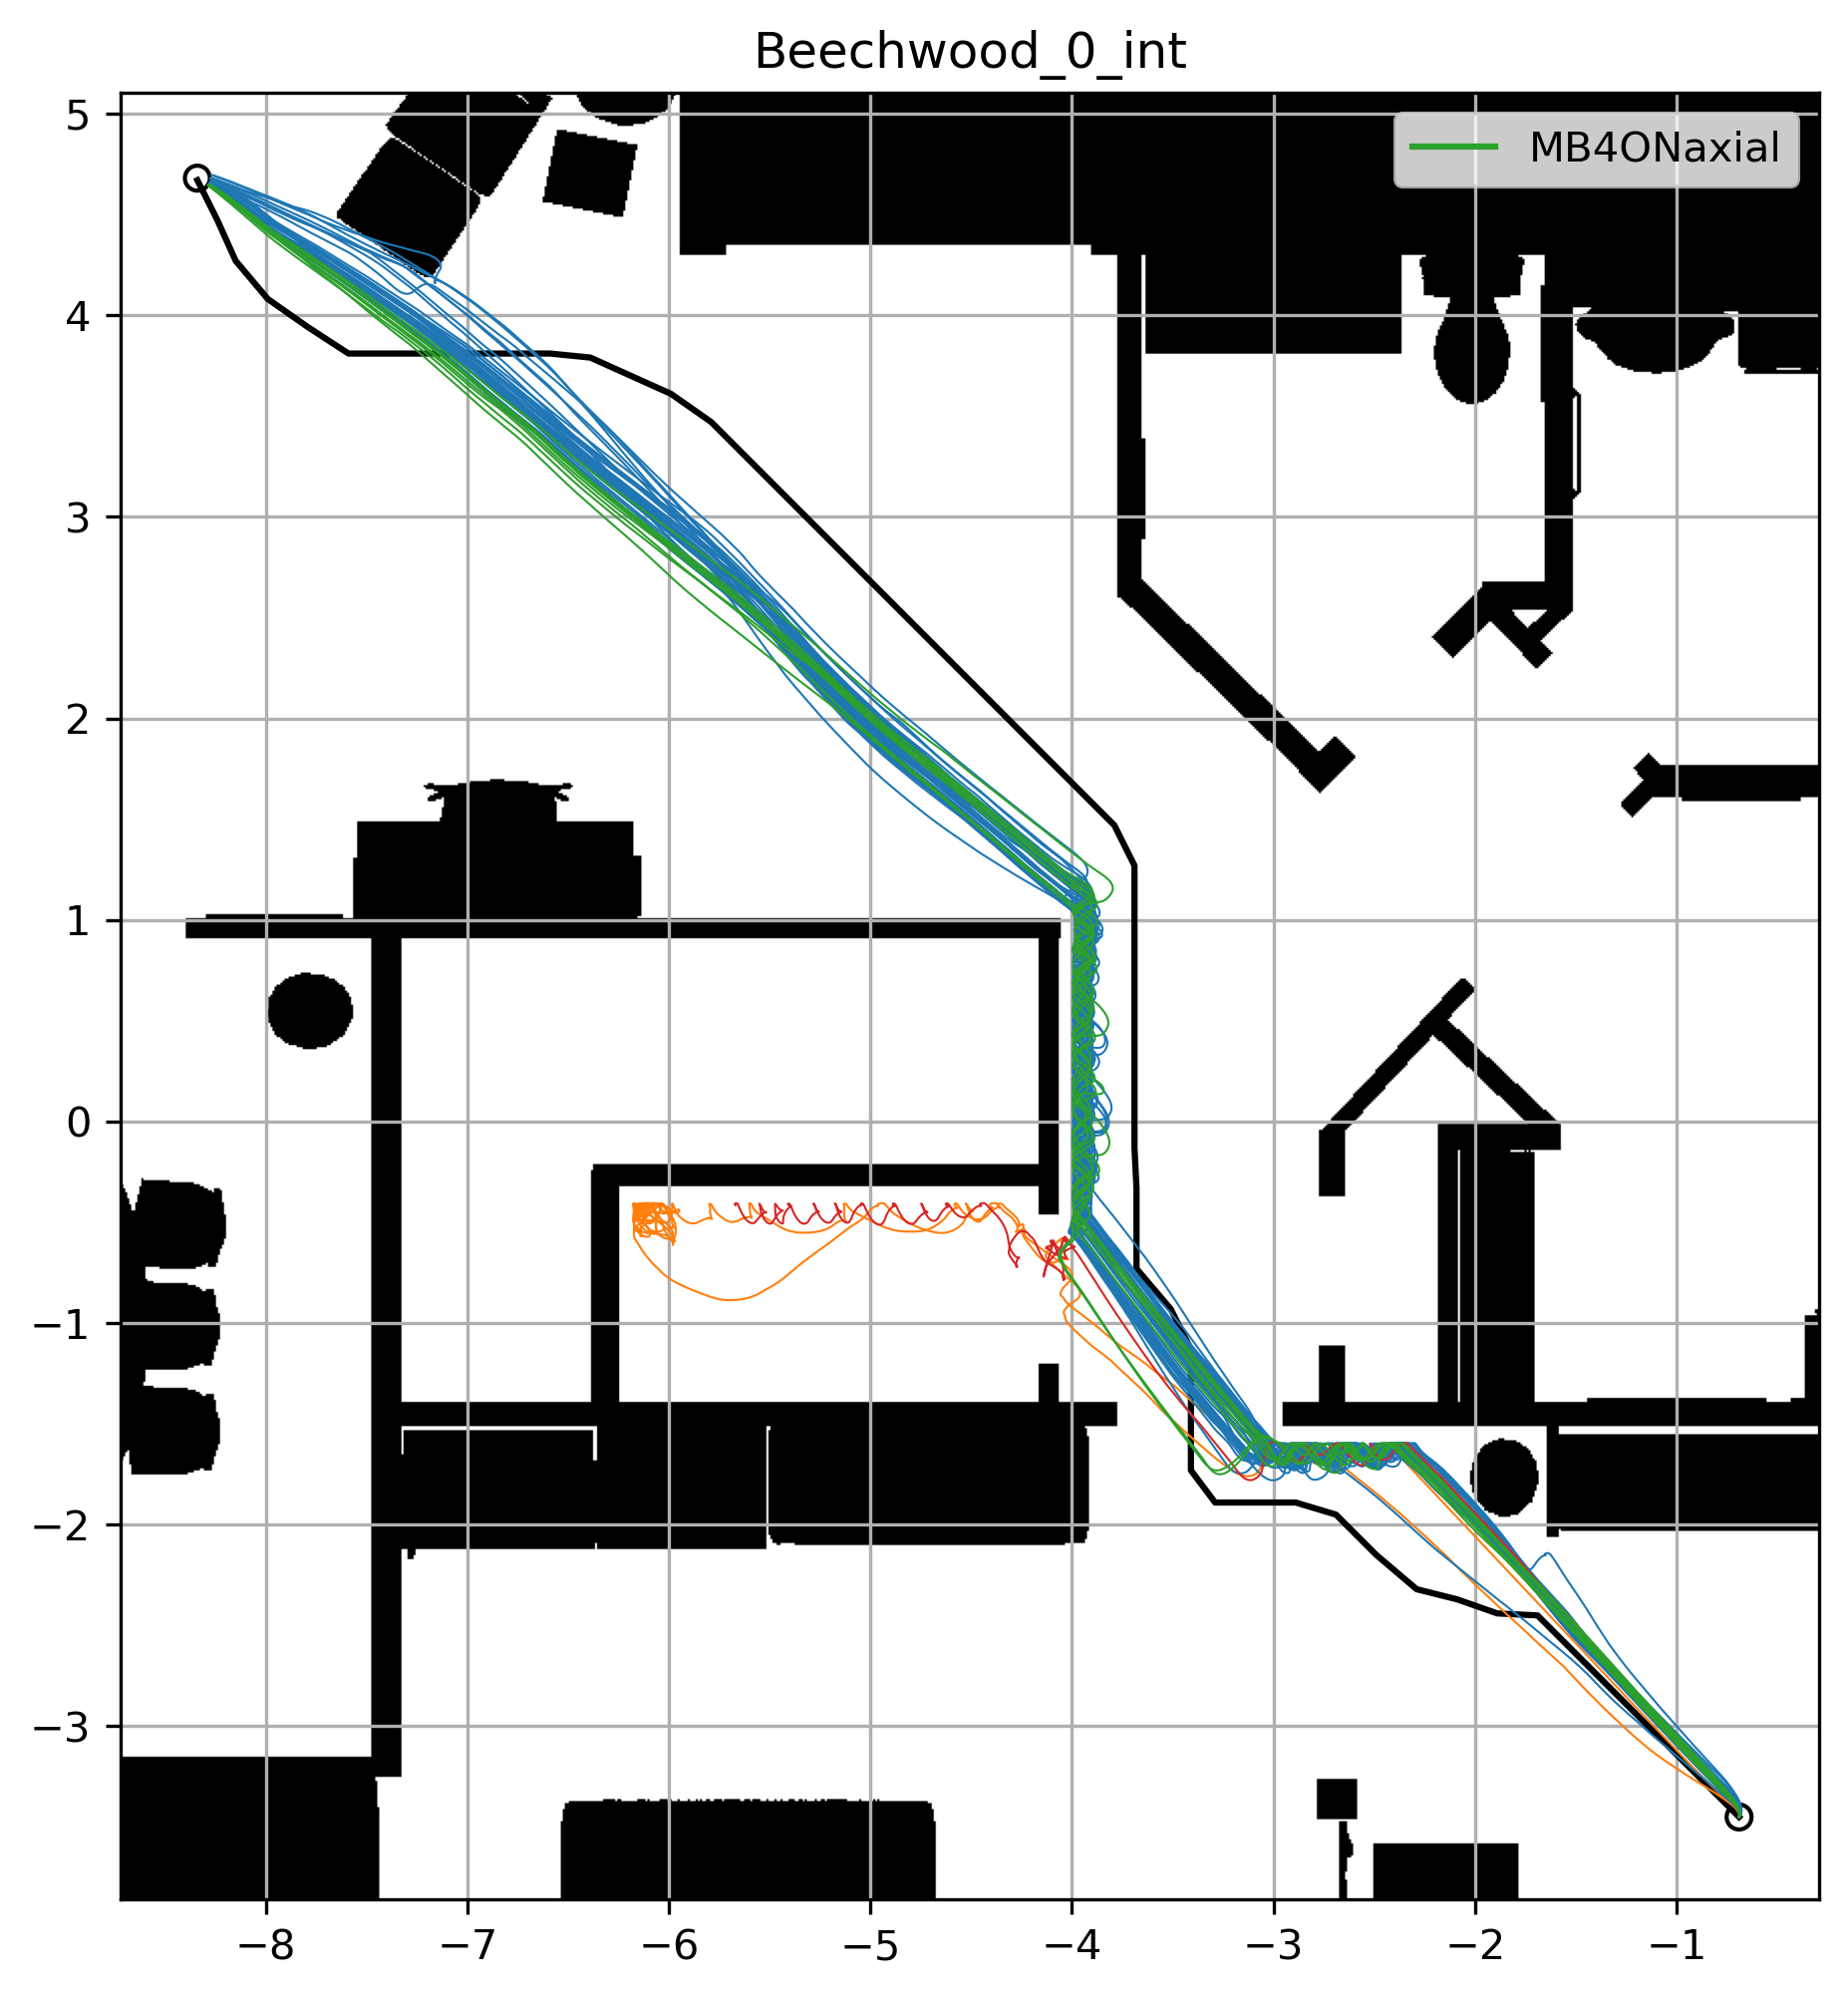

In [7]:
fig, ax = plt.subplots(figsize=(8, 8), dpi=300)

ax.plot(*shortest_path.T, color='k')

for trial in range(n_trial):
    model_name, color = model_names[1], ls_color[1]
    x, y = alldata[model_name]['x'][trial], alldata[model_name]['y'][trial]
    if trial <= 1:
        color = 'tab:orange'
    elif 1 < trial < 41:
        color = 'tab:blue'
    elif trial == 41:
        color = 'tab:red'
    elif trial > 41:
        color = 'tab:green'
    ax.plot(x, y,
           c=color,
           lw=.5)
        
                        
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
       
    
ax.plot([], [], c=color, label=model_name)
ax.scatter(*pos_start_goal, edgecolor='k', facecolor='none', marker='o')


ax.set_aspect('equal')
ax.legend()

floorplan = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/data/ig_dataset/scenes/{}/layout/floor_trav_no_door_0.png'.format(scene_name)
draw_floorplan(ax, floorplan, 0.01)
ax.set_xlim(xlim)
ax.set_ylim(ylim)    
ax.grid()
ax.set_title(scene_name)

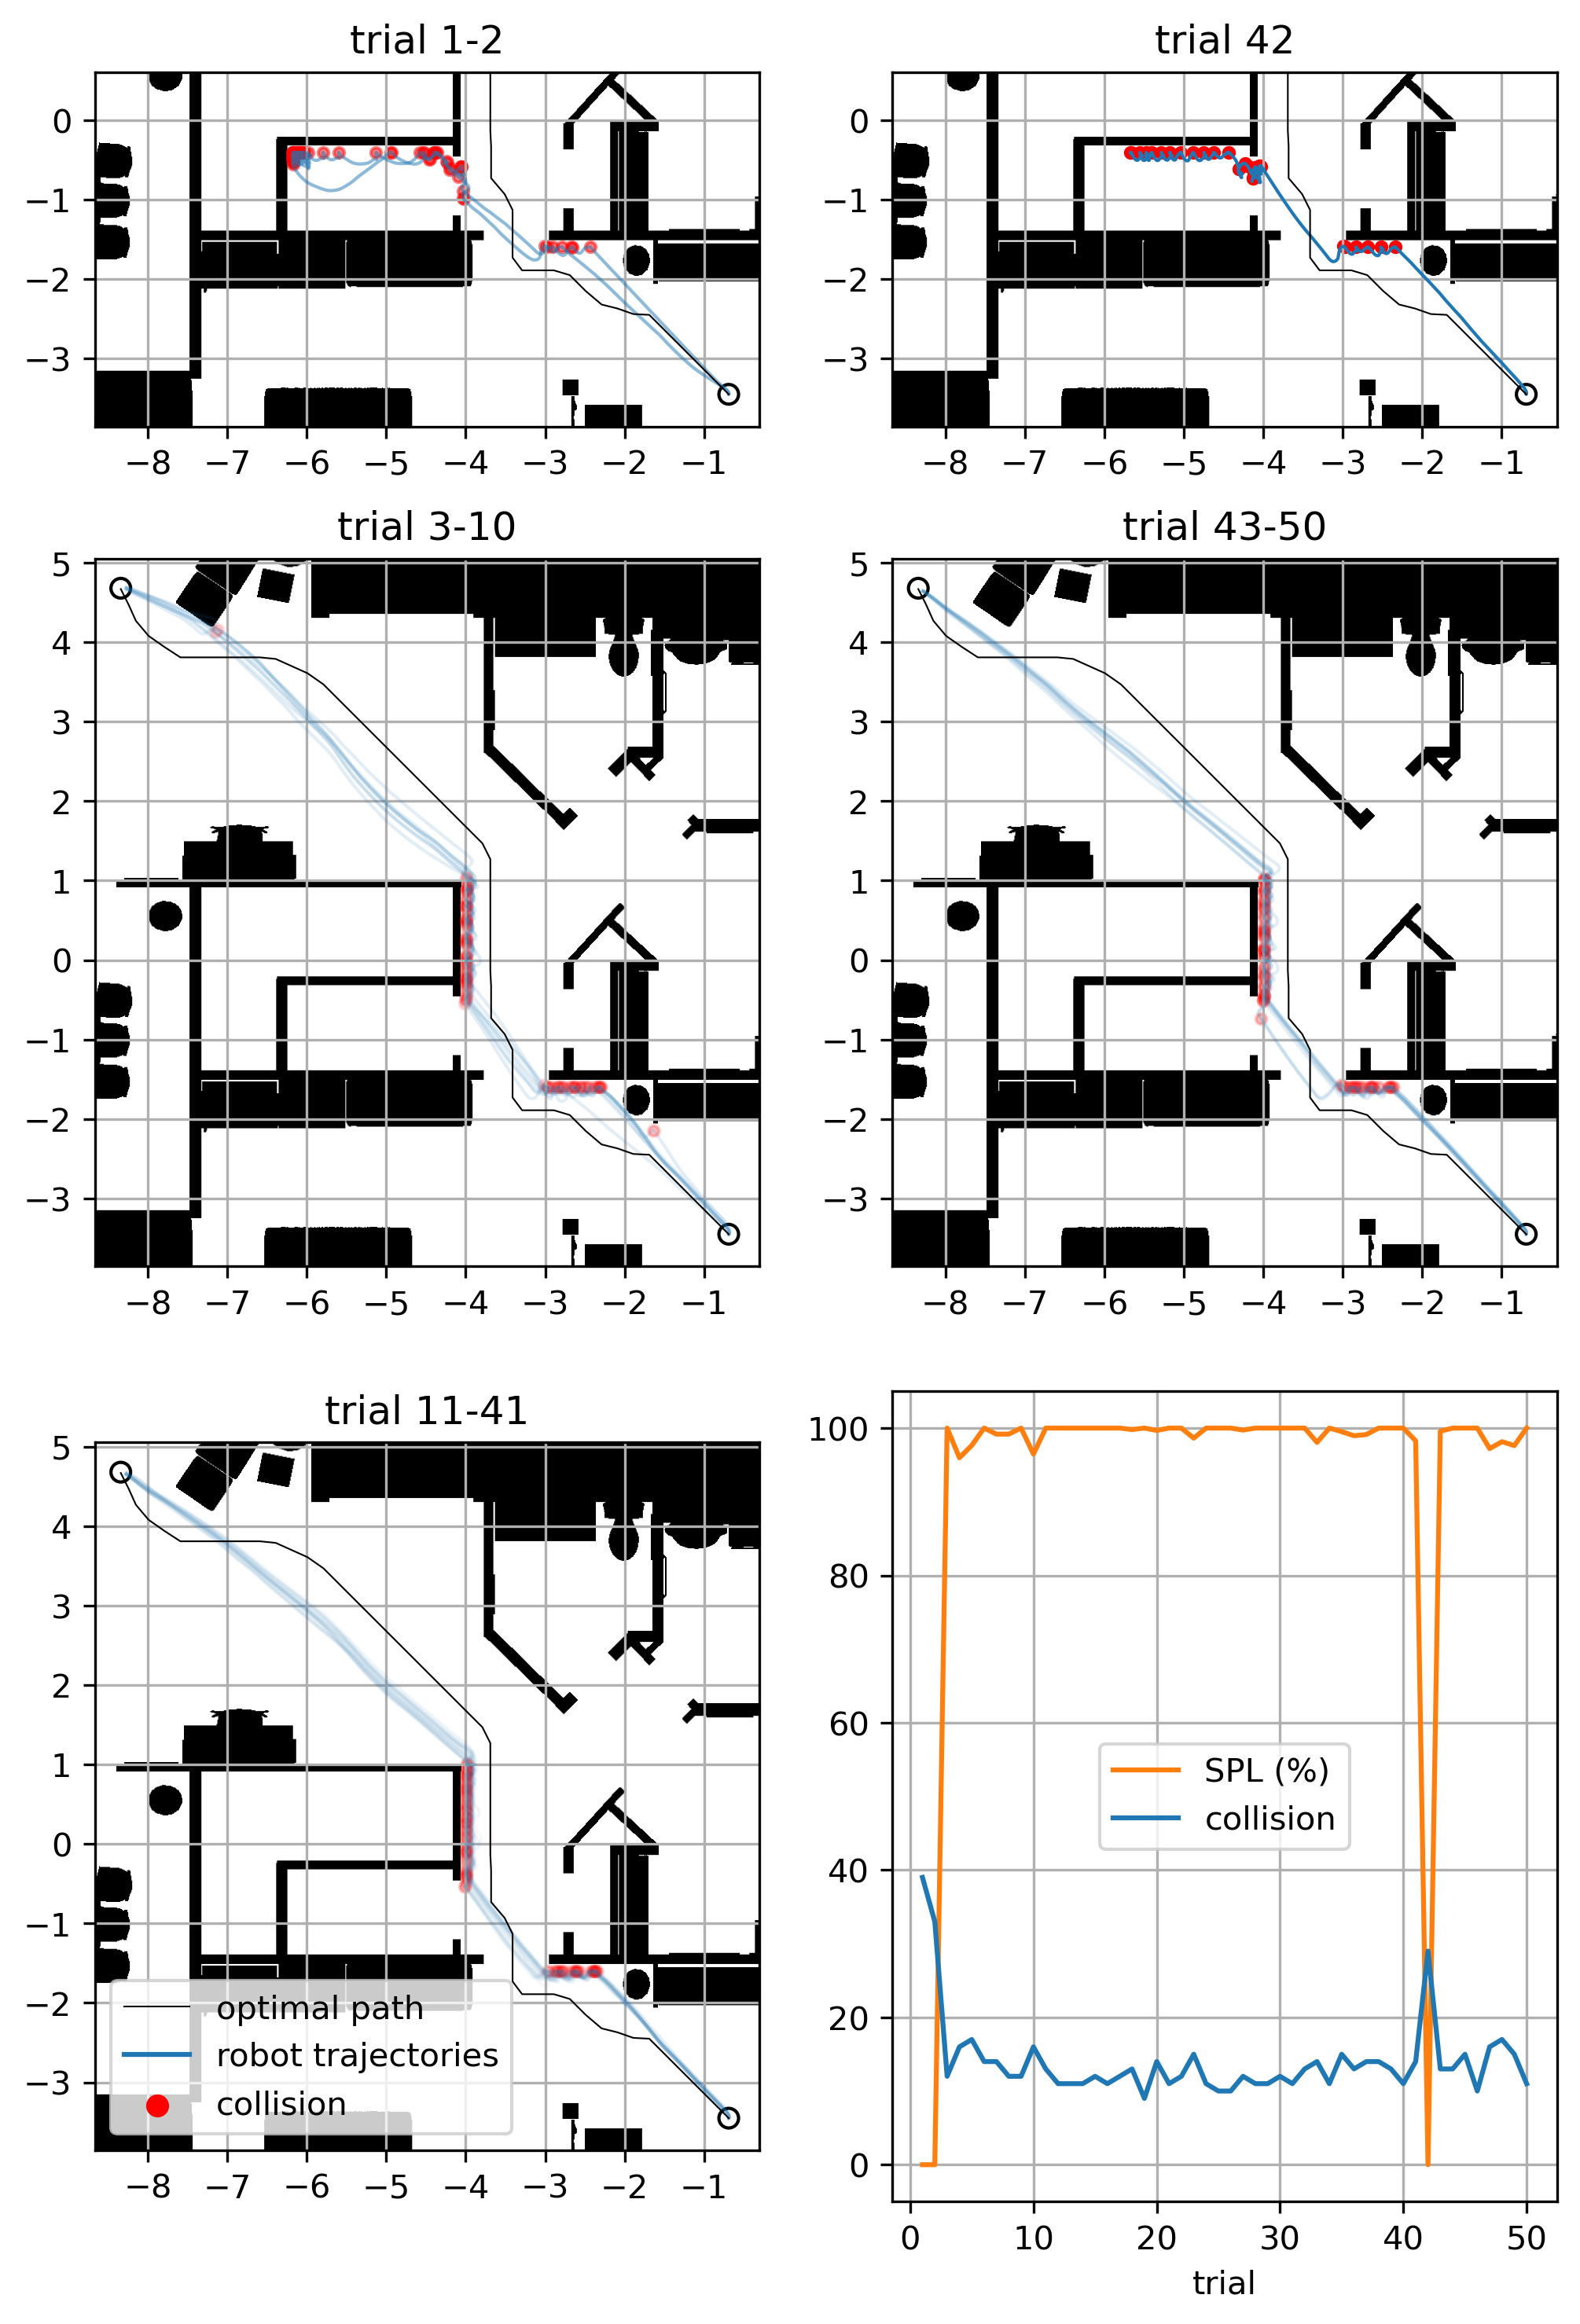

In [14]:
model_name, color = model_names[1], ls_color[1]

fig, axes = plt.subplot_mosaic('''
                                ad
                                be
                                be
                                cf
                                cf''', figsize=(8, 12), dpi=300)
n_col, v_spl = [], []

for trial in range(n_trial):
    
    x, y = alldata[model_name]['x'][trial], alldata[model_name]['y'][trial]
    collision_idx = alldata[model_name]['f'][trial] > 100 
    n_col.append(np.count_nonzero(collision_idx))
    v_spl.append(spl(np.transpose([x, y]), pos_start_goal[:, 1], shortest_dist))
    
    if trial <= 1:
        al = 1 / 2
        ax = axes['a']
    elif 1 < trial <= 9:
        al = 1 / 8
        ax = axes['b']       
    elif 9 < trial < 41:
        al = 1 / 31
        ax = axes['c']
    elif trial == 41:
        al = 1 / 1
        ax = axes['d']
    elif trial > 41:
        al = 1 / 8
        ax = axes['e']
    ax.plot(x, y,
           c='tab:blue', alpha=al,
           lw=1)
    ax.scatter(x[collision_idx], y[collision_idx], color='r', marker='o', alpha=al, s=10)
        
                        
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
     
        
for ak, trial in zip('abcde', ['1-2', '3-10', '11-41', '42', '43-50']):
    ax = axes[ak]
    ax.plot(*shortest_path.T, color='k', lw=0.5, label='optimal path')
    
    ax.plot([], [], c='tab:blue', label='robot trajectories')
    ax.scatter(*pos_start_goal, edgecolor='k', facecolor='none', marker='o')
    ax.scatter([], [], color='r', label='collision')


    ax.set_aspect('equal')

    
    floorplan = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/data/ig_dataset/scenes/{}/layout/floor_trav_no_door_0.png'.format(scene_name)
    draw_floorplan(ax, floorplan, 0.01)
    ax.set_xlim(xlim)
    if ak in 'ad':
        ax.set_ylim([ylim[0], np.mean(ylim)])
    else:
        ax.set_ylim(ylim)    
    ax.grid()
    ax.set_title('trial ' + trial)
    ax.set_xticks(np.arange(-8,0))

axes['c'].legend()
    
trial_idx = np.arange(n_trial) + 1
cx = axes['f']
cx.plot(trial_idx, np.array(v_spl) * 100, c='tab:orange', label='SPL (%)')
cx.plot(trial_idx, n_col, label='collision')

    
# cx.set_yticks([0, 30, 60, 90, 100])
cx.set_ylim([-5, 105])
cx.set_xticks([0, 10, 20, 30, 40, 50])
cx.grid()
cx.set_xlabel('trial')
cx.legend()

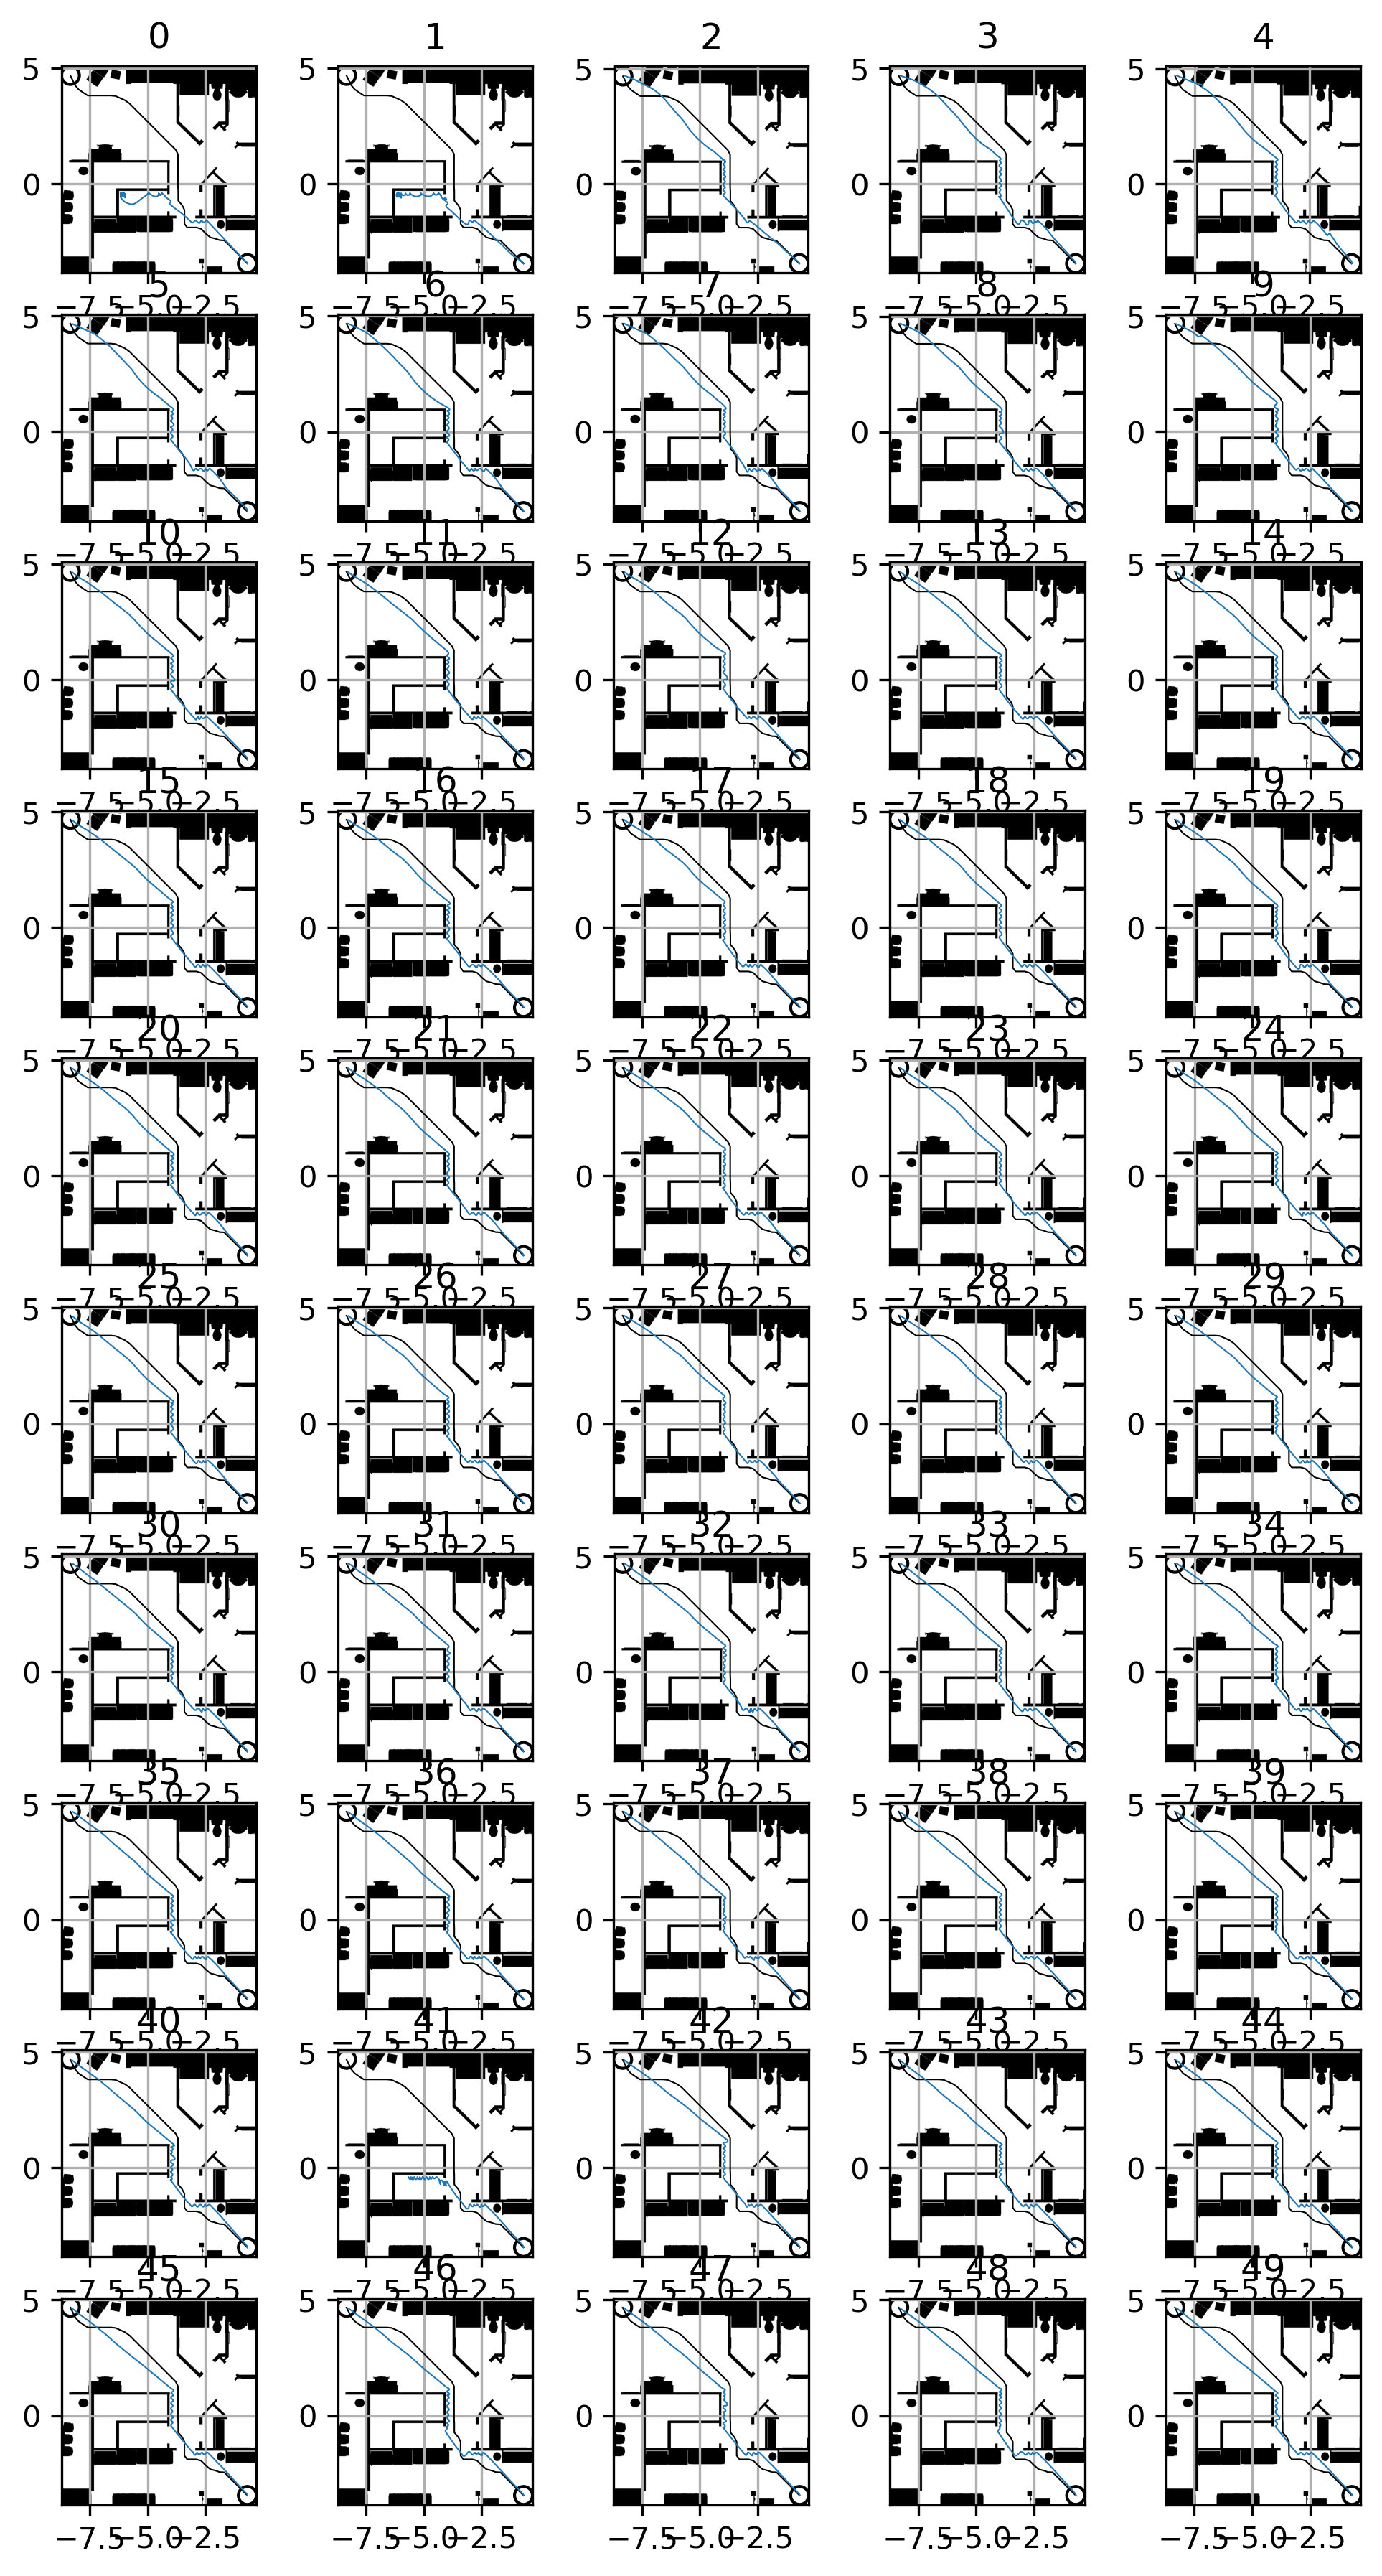

In [9]:
model_name, color = model_names[1], ls_color[1]

fig, axes = plt.subplots(10, 5, figsize=(8, 15), dpi=300)


for trial, ax in enumerate(axes.flatten()):
    
    ax.plot(*shortest_path.T, color='k', lw=0.5)
    x, y = alldata[model_name]['x'][trial], alldata[model_name]['y'][trial]
    
        
    if trial >= -45:
        ax.plot(x, y, 
                c=color, 
                lw=.5)
                        
    xlim, ylim = ax.get_xlim(), ax.get_ylim()
       
    
    ax.plot([], [], c=color, label=model_name)
    ax.scatter(*pos_start_goal, edgecolor='k', facecolor='none', marker='o')


    ax.set_aspect('equal')
#     ax.legend()

    floorplan = '/home/yihelu/miniconda3/envs/igibson/lib/python3.8/site-packages/igibson/data/ig_dataset/scenes/{}/layout/floor_trav_no_door_0.png'.format(scene_name)
    draw_floorplan(ax, floorplan, 0.01)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)    
    ax.grid()
    ax.set_title(trial)